In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import find_clusters
import astropy.io.fits as fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.coordinates import SkyCoord
import cv2

## read in photometric catalog
## appropriate cuts for what photometry to use as input

In [2]:
# example photometric input for clustering algorithm, all you need is the coordinates of the sources
catalog = pd.read_csv('~/NGC6946/clusters/example-catalog.csv')
# make appropriate quality cuts for the sources you are wanting to find clusters with
df = catalog[(catalog.snr336>4)&(catalog.snr275>4)]

In [3]:
# read in F275W (reference filter) drizzled image:
hdu = fits.open('~/NGC6946/clusters/15877_NGC6946-8_syn_F275W_drz.chip1.fits')
f275w = hdu[0].data
header = hdu[0].header
wcs_275 = WCS(header)
hdu.close()

# convert ra and dec into x and y coords in mosaicked frame.
x,y = wcs_275.world_to_pixel(SkyCoord(ra=df.RA,dec=df.dec,unit=(u.deg,u.deg)))

## make stellar density map 

In [4]:
# binwidth and number of bins is determined by resolution of the imaging and distance to cluster
# example here: binwidth = 4, NGC 6946 is fairly far and the smoothing for the kde is minimized to make the stellar density pop 
# number of x and y bins is roughly 2 twice the number of pixels on the x and y axis 
# each pixel is about 1.5 parsec at this distance, so we are choosing 8000 to have sufficient resolution

(1000.0, 1500.0)

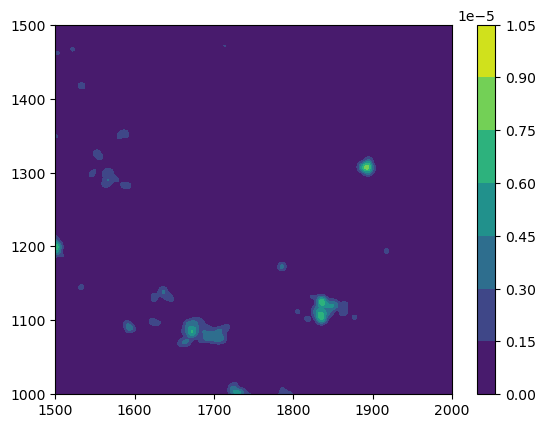

In [5]:
X, Y, Z = kde2D(x,y,4,xbins=8000j,ybins=8000j) # <- takes forever to run, writing to a csv to read in later

plt.contourf(X,Y,Z)
plt.colorbar()
plt.xlim(1500,2000)
plt.ylim(1000,1500)

## create a smoothed stellar density map

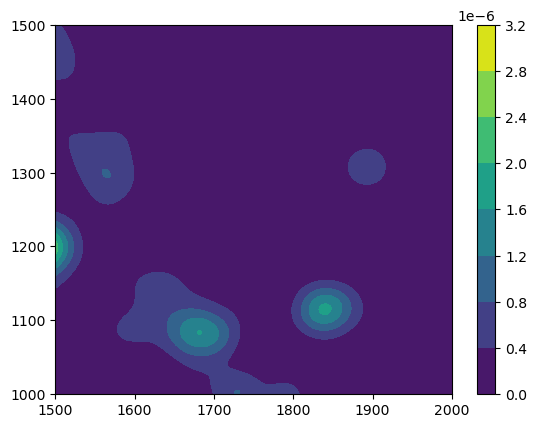

In [7]:
X_smooth, Y_smooth, Z_smooth = kde2D(x,y,20,xbins=8000j,ybins=8000j)

plt.contourf(X_smooth,Y_smooth,Z_smooth)
plt.colorbar()
plt.xlim(1500,2000)
plt.ylim(1000,1500)
plt.show()

## perform unsharp masking

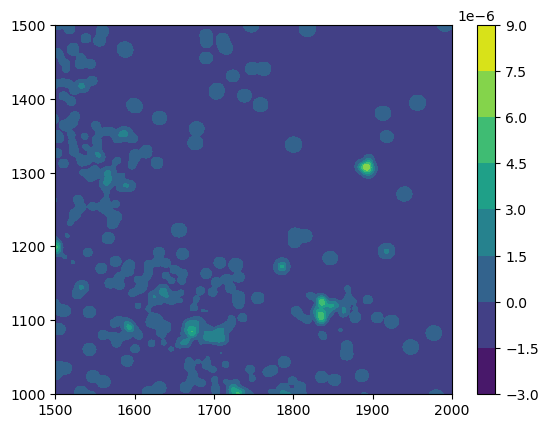

In [9]:
sharpened = find_clusters.sharpened(Z,Z_smooth)
plt.contourf(X,Y,sharpened)
plt.colorbar()
plt.xlim(1500,2000)
plt.ylim(1000,1500)
plt.show()

## take gradient on unsharp image

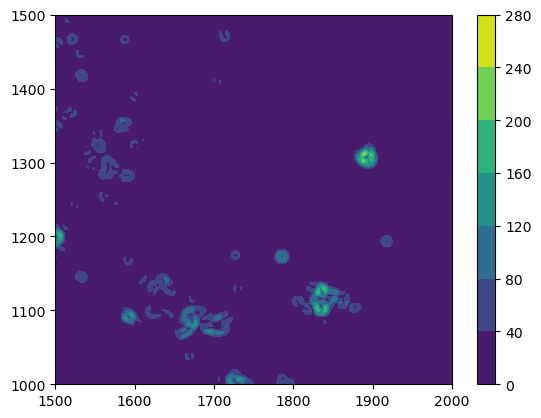

In [11]:
mag, theta, dx, dy = find_clusters.grad(sharpened)
plt.contourf(X,Y,mag)
plt.colorbar()
plt.xlim(1500,2000)
plt.ylim(1000,1500)
plt.show()

## non-maximum suppression

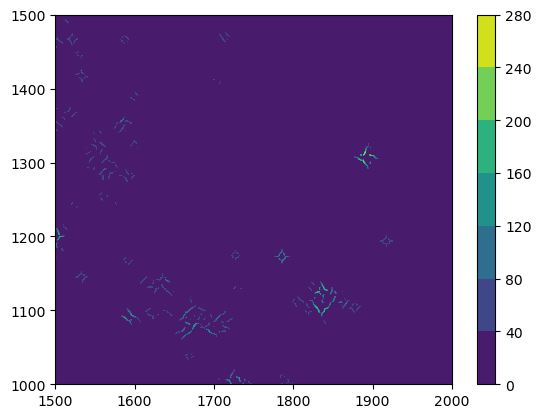

In [13]:
nms = find_clusters.NonMaxSupWithInterpol(mag,theta,dx,dy)
plt.contourf(X,Y,nms)
plt.colorbar()
plt.xlim(1500,2000)
plt.ylim(1000,1500)
plt.show()

## double threshold hysteresis:

Otsu's Threshold: 37.0 
Triangle Threshold: (3.3499999999999996, 6.65) 
Manual Threshold: (0.0, 0.0)


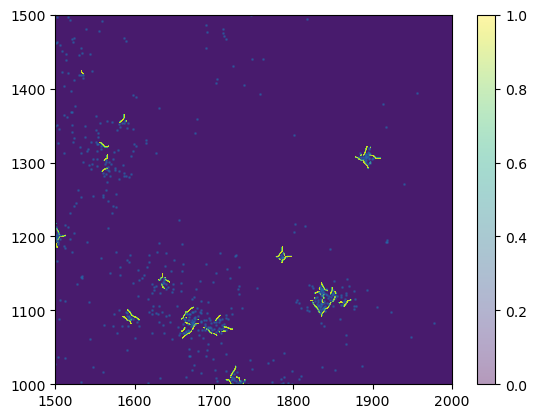

In [15]:
# do this does automatically select thresholds based on sigma
# can choose which threshold to use - Otsu's threshold is a good estimate

otsu_thresh,_ = cv2.threshold(mag.astype(np.uint8),0,255,cv2.THRESH_OTSU)
triangle_thresh, _ = cv2.threshold(mag.astype(np.uint8),0,255,cv2.THRESH_TRIANGLE)
manual_thresh= np.median(mag.astype(np.uint8))

def get_range(threshold, sigma=0.33):
    return (1-sigma)*threshold,(1+sigma)*threshold

otsu_thresh = find_clusters.get_range(otsu_thresh)
triangle_thresh = find_clusters.get_range(triangle_thresh)
manual_thresh = find_clusters.get_range(manual_thresh)

print(f"Otsu's Threshold: {otsu_thresh} \nTriangle Threshold: {triangle_thresh} \nManual Threshold: {manual_thresh}")
hyst_img = find_clusters.ThreshHyst(nms,triangle_thresh[1],otsu_thresh*2)
plt.contourf(X,Y,hyst_img)
plt.scatter(x,y,s=1,alpha=.4)
plt.colorbar()
plt.xlim(1500,2000)
plt.ylim(1000,1500)
plt.show()

In [16]:
# labels clusters with index starting from 0
labels, edges = find_clusters.get_labels(hyst_img)

# convert coordinates to xy and wcs coordinates
xy_arr, wcs_coords = find_clusters.convert_to_wcs(labels,X,Y,edges,wcs_275)

# create dataframe of coordinates each cluster
df = find_clusters.make_dataframe(xy_arr, wcs_coords)

In [17]:
# coordinates of each cluster
df

,x,y,ra,dec,label
0,112.827067,2402.149670,308.788884,60.172977,0.0
1,113.348265,2395.591727,308.789006,60.172938,0.0
2,113.348265,2402.149670,308.788879,60.172972,0.0
3,113.869463,2395.591727,308.789001,60.172932,0.0
4,113.869463,2401.603175,308.788884,60.172964,0.0
...,...,...,...,...,...
0,1312.625440,1877.514157,308.786425,60.158617,1828.0
1,1312.625440,1878.060653,308.786414,60.158620,1828.0
0,979.058560,2044.741727,308.786693,60.162722,1829.0
1,979.058560,2045.288222,308.786682,60.162725,1829.0


In [ ]:
# save dataframe
df.to_pickle('cluster-coords.pkl')